In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("apps.csv")

In [3]:
df.head(5)

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   str    
 6   Installs        9659 non-null   str    
 7   Type            9658 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(1), int64(2), str(11)
memory usage: 1.9 MB


In [5]:
df.shape

(9659, 14)

In [6]:
df.nunique()

Unnamed: 0        9659
App               9659
Category            33
Rating              39
Reviews           5330
Size               460
Installs            21
Type                 2
Price               92
Content Rating       6
Genres             118
Last Updated      1377
Current Ver       2817
Android Ver         33
dtype: int64

In [7]:
df.isna().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [8]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(df.shape)

(7021, 14)


In [9]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [10]:
df.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [11]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [12]:
print(df.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')


In [13]:
# Convert Reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Convert Installs (remove + and ,)
df['Installs'] = df['Installs'].str.replace('+','').str.replace(',','')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Convert Price
df['Price'] = df['Price'].str.replace('$','')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [14]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M','')) * 1e6
    elif 'k' in size:
        return float(size.replace('k','')) * 1e3
    else:
        return None

df['Size'] = df['Size'].apply(convert_size)

## Outlier Detection

In [15]:
def count_outliers(df, cols):
    
    outlier_count = {}
    
    for col in cols:
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        outlier_count[col] = len(outliers)
    
    return outlier_count

In [16]:
numeric_cols = ['Reviews','Installs','Price','Size']

before_outliers = count_outliers(df, numeric_cols)

print("Outliers BEFORE removal:")
for k,v in before_outliers.items():
    print(f"{k}: {v}")

Outliers BEFORE removal:
Reviews: 1166
Installs: 1313
Price: 539
Size: 373


In [17]:
df_clean = df.copy()

for col in numeric_cols:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) & (df_clean[col] <= upper)
    ]

In [18]:
after_outliers = count_outliers(df_clean, numeric_cols)

print("\nOutliers AFTER removal:")
for k,v in after_outliers.items():
    print(f"{k}: {v}")


Outliers AFTER removal:
Reviews: 681
Installs: 0
Price: 0
Size: 99


In [19]:
print("\nDataset Size:")
print("Before:", df.shape)
print("After :", df_clean.shape)


Dataset Size:
Before: (7021, 13)
After : (4545, 13)


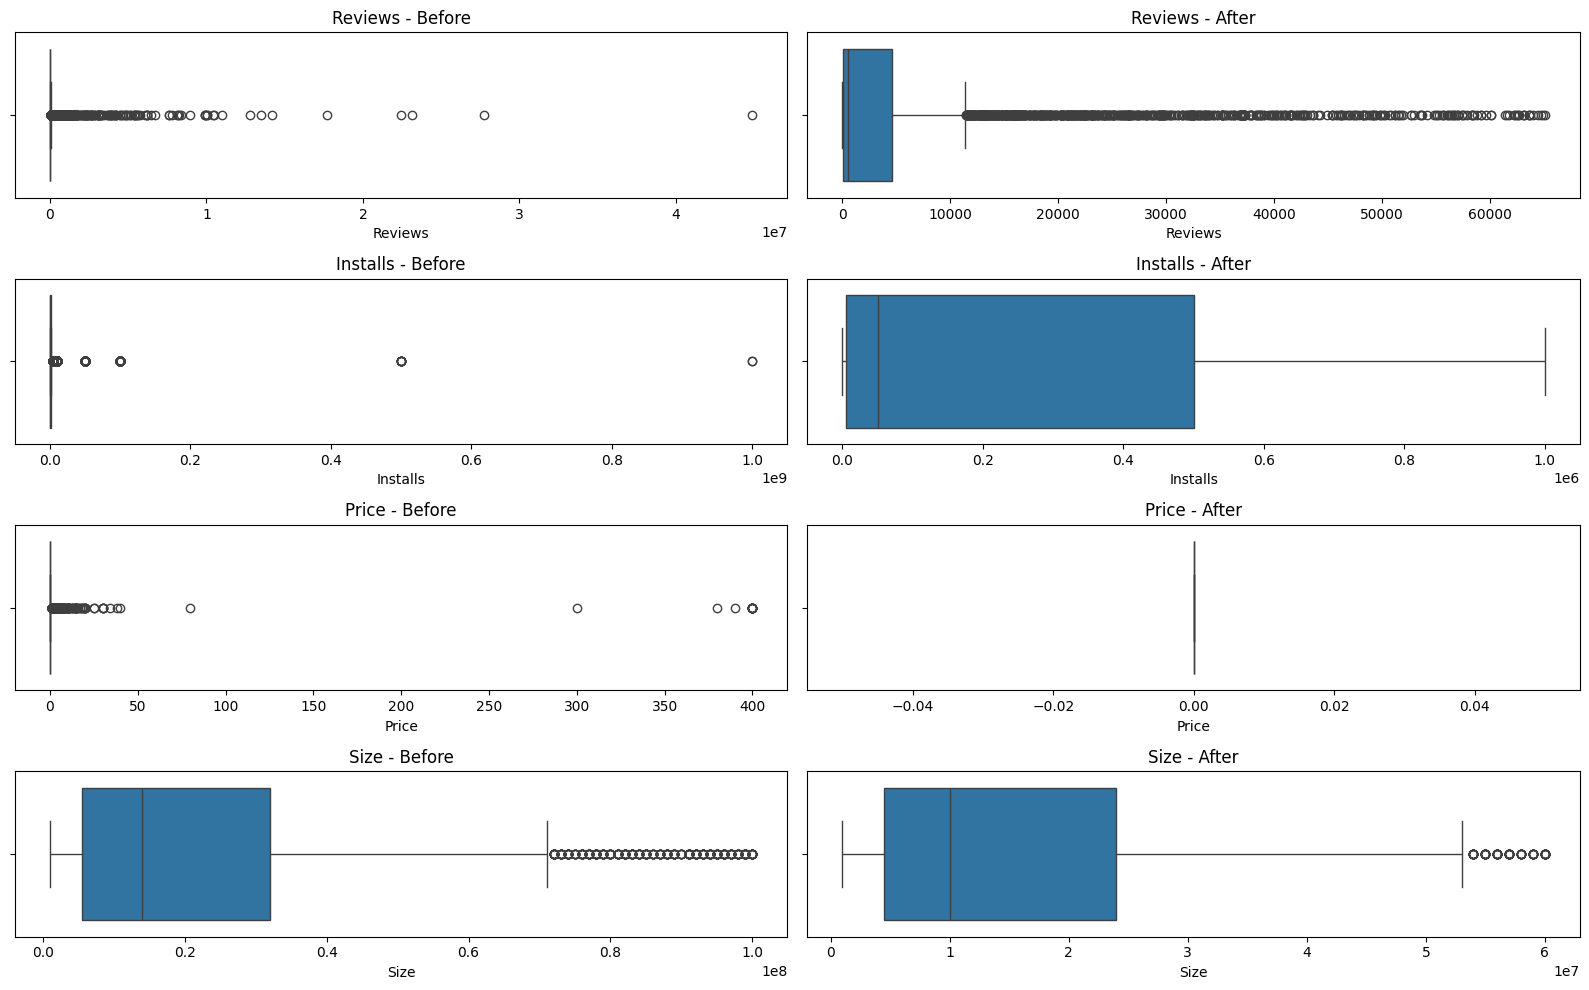

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

for i, col in enumerate(numeric_cols):
    
    # BEFORE
    plt.subplot(4,2,2*i+1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Before")
    
    # AFTER
    plt.subplot(4,2,2*i+2)
    sns.boxplot(x=df_clean[col])
    plt.title(f"{col} - After")

plt.tight_layout()
plt.show()

In [23]:
df_clean.dropna(inplace=True)

In [24]:
df_clean.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [25]:
def rating_category(r):
    if r >= 4:
        return "Good"
    elif r >= 3:
        return "Average"
    else:
        return "Bad"

df_clean['Rating_Class'] = df_clean['Rating'].apply(rating_category)

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Category','Type','Content Rating','Genres']

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

In [27]:
features = ['Category','Reviews','Size','Installs','Type','Price','Content Rating','Genres']

X = df_clean[features]
y = df_clean['Rating_Class']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.7073707370737073


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Average       0.44      0.20      0.27       220
         Bad       0.11      0.05      0.07        39
        Good       0.76      0.92      0.83       650

    accuracy                           0.71       909
   macro avg       0.43      0.39      0.39       909
weighted avg       0.65      0.71      0.66       909



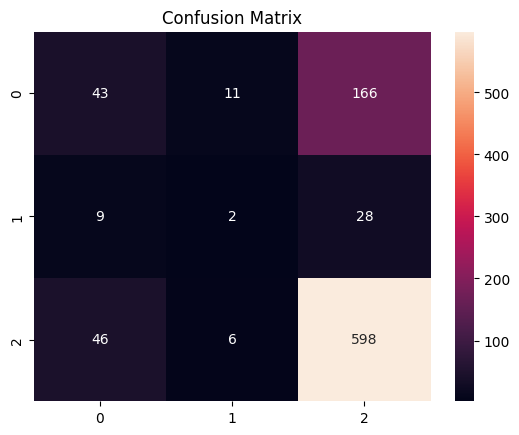

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.show()

In [32]:
importance = rf.feature_importances_

import pandas as pd

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_df)

          Feature  Importance
1         Reviews    0.348372
2            Size    0.306515
7          Genres    0.122518
3        Installs    0.099202
0        Category    0.097894
6  Content Rating    0.025498
5           Price    0.000000
4            Type    0.000000


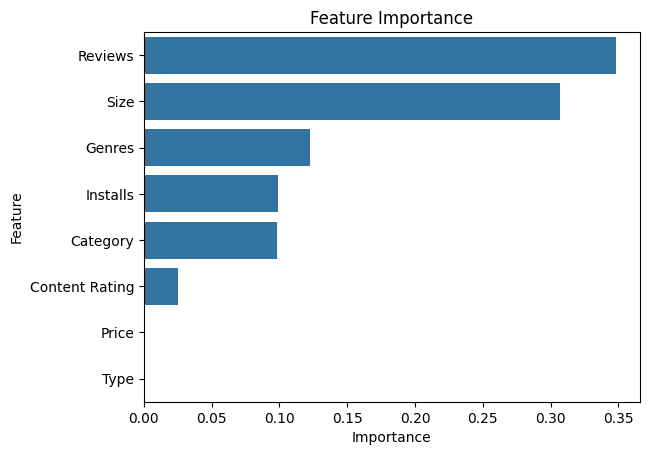

In [33]:
sns.barplot(x='Importance', y='Feature', data=feat_df)

plt.title("Feature Importance")

plt.show()

In [59]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42,max_depth=3)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree:", dt_acc)

Decision Tree: 0.7150715071507151


In [61]:
from sklearn.tree import DecisionTreeClassifier

dt_small = DecisionTreeClassifier(max_depth=3, random_state=42)

dt_small.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

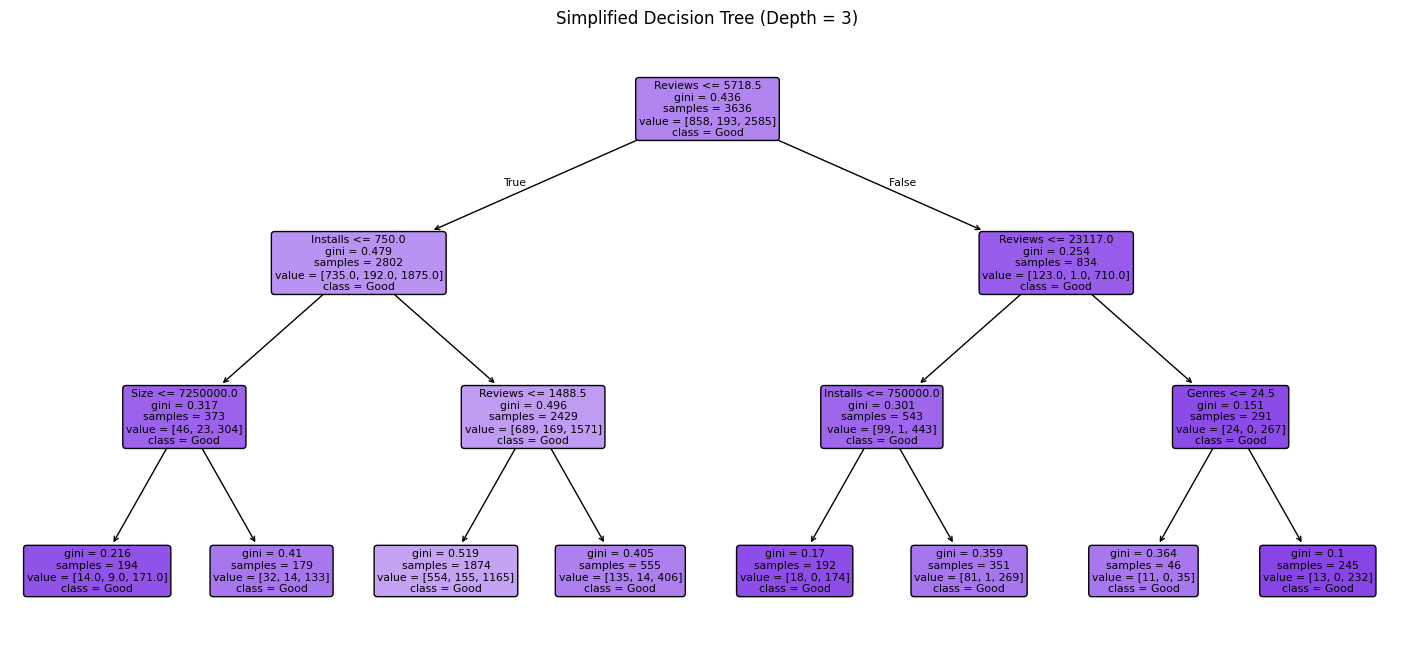

In [ ]:
from sklearn.tree import plot_tree


plt.figure(figsize=(18,8))

plot_tree(
    dt_small,
    feature_names=X.columns,
    class_names=['Bad','Average','Good'],
    filled=True,
    rounded=True
)

plt.title("Simplified Decision Tree (Depth = 3)")

plt.show()

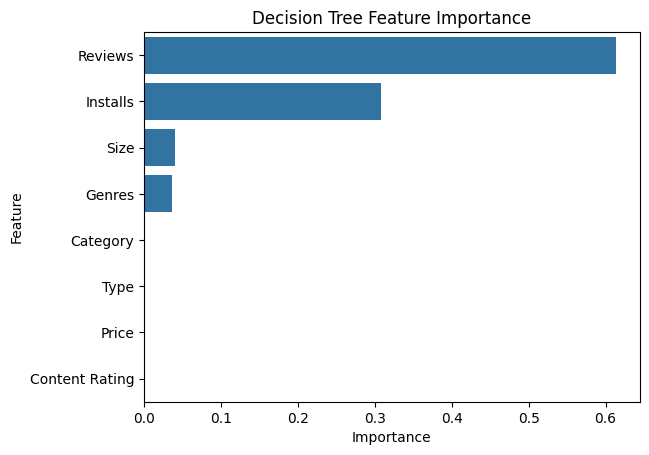

In [63]:
import pandas as pd
import seaborn as sns

importance = dt.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df)

plt.title("Decision Tree Feature Importance")

plt.show()

In [ ]:
## ! pip install xgboost

In [36]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()

y = le_target.fit_transform(df_clean['Rating_Class'])

In [37]:
X = df_clean[['Category','Reviews','Size','Installs','Type','Price','Content Rating','Genres']]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

c:\Users\ANKIT AGRAWAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [40]:
from sklearn.metrics import accuracy_score

y_pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.6908690869086909


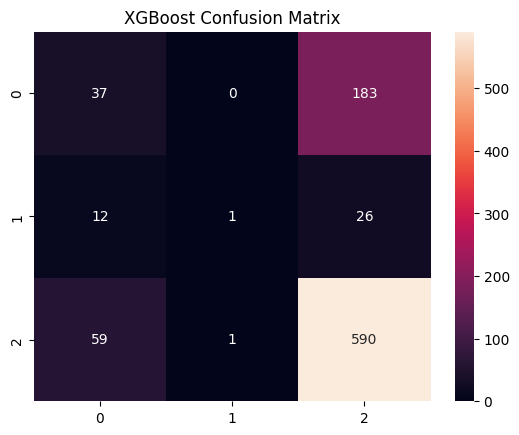

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("XGBoost Confusion Matrix")
plt.show()

In [42]:
import pandas as pd

importance = xgb.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_df)

          Feature  Importance
3        Installs    0.201486
1         Reviews    0.178396
7          Genres    0.173167
6  Content Rating    0.151267
0        Category    0.151157
2            Size    0.144528
5           Price    0.000000
4            Type    0.000000


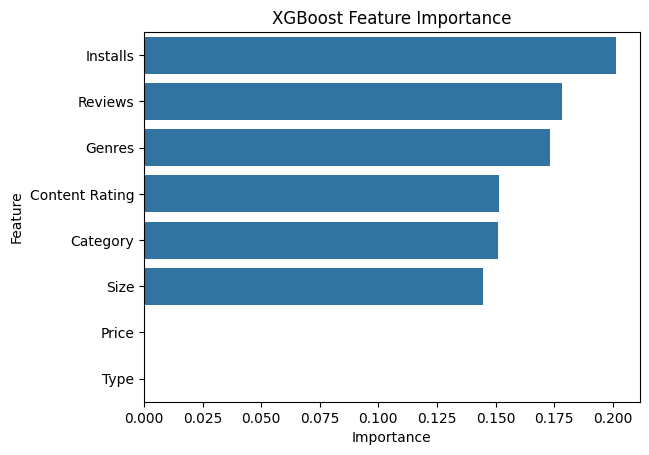

In [43]:
sns.barplot(x='Importance', y='Feature', data=feat_df)

plt.title("XGBoost Feature Importance")

plt.show()

In [54]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Decision Tree","Random Forest","XGBoost"],
    "Accuracy": [dt_acc, acc, xgb_acc]
})

print(results)

           Model  Accuracy
0  Decision Tree  0.710671
1  Random Forest  0.707371
2        XGBoost  0.690869


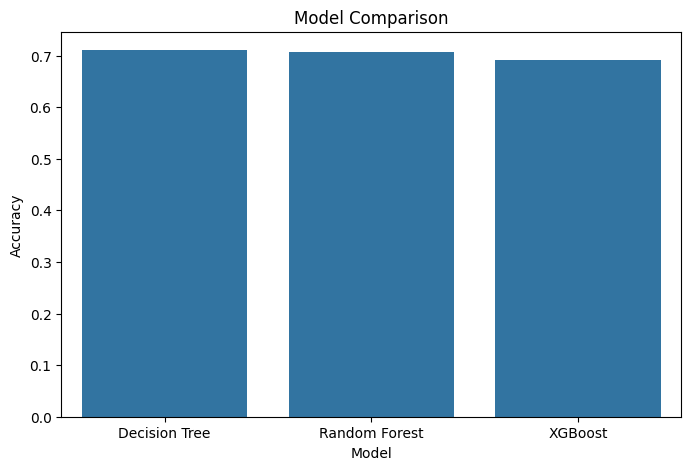

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Model Comparison")

plt.show()


## Correlation Heatmap

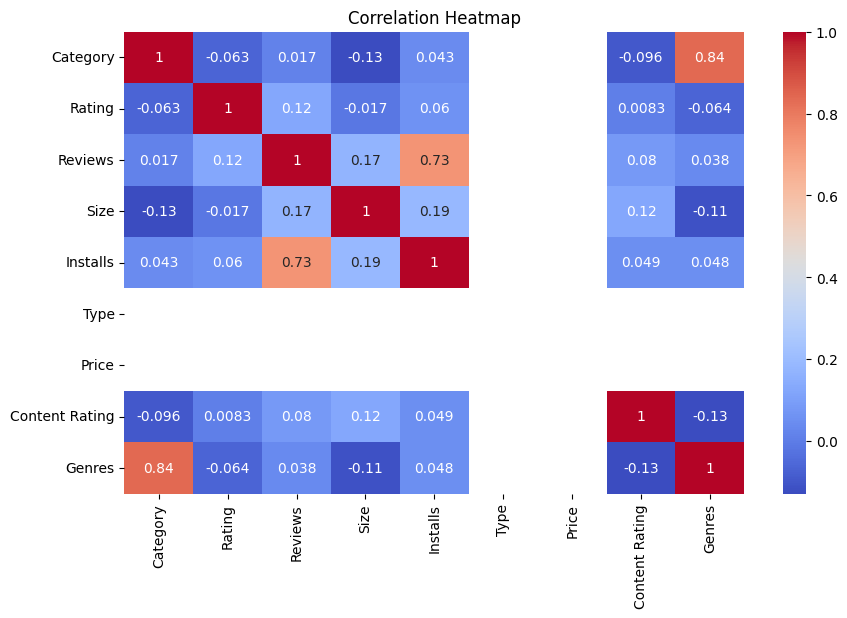

In [82]:
plt.figure(figsize=(10,6))

corr = df_clean.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## Rating Distribution

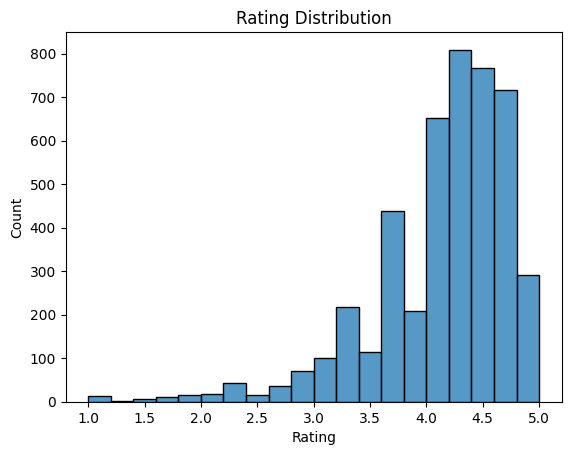

In [83]:
sns.histplot(df_clean['Rating'], bins=20)

plt.title("Rating Distribution")

plt.show()

## Installs vs Rating

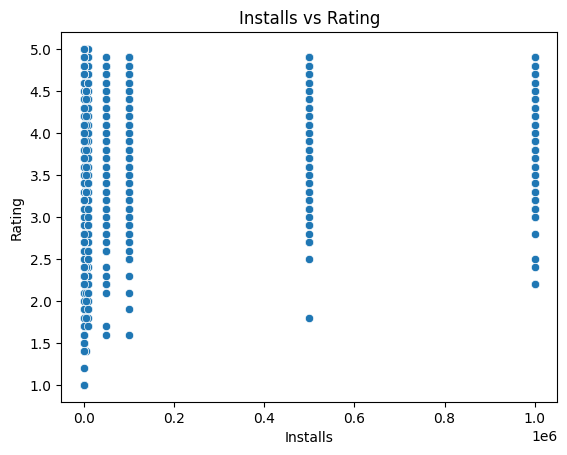

In [85]:
sns.scatterplot(
    x='Installs',
    y='Rating',
    data=df_clean
)

plt.title("Installs vs Rating")

plt.show()

## Reviews vs Rating

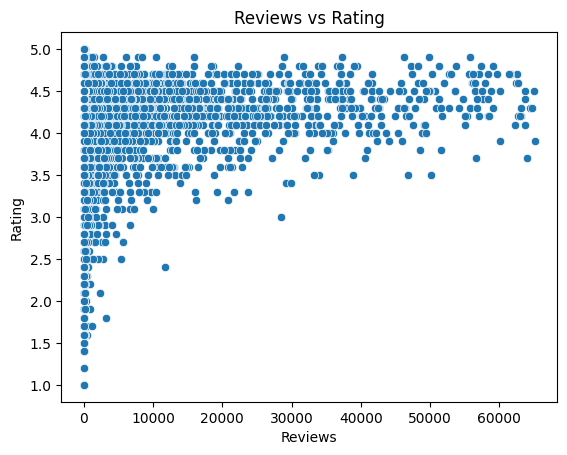

In [86]:
sns.scatterplot(
    x='Reviews',
    y='Rating',
    data=df_clean
)

plt.title("Reviews vs Rating")

plt.show()

## Rating Class Pie Chart (BEST ONE)

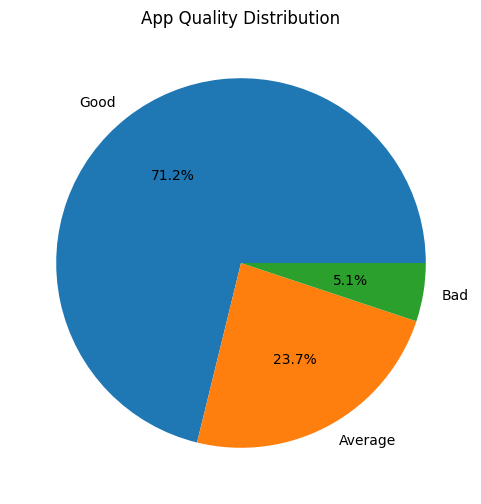

In [89]:
rating_counts = df_clean['Rating_Class'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%'
)

plt.title("App Quality Distribution")

plt.show()

In [ ]:
labels = [mapping.get(i, str(i)) for i in content_counts.index] # pyright: ignore[reportUndefinedVariable]

In [104]:
print(df_clean['Content Rating'].unique())

[1 2 4 3 0 5]


In [105]:
mapping = {
    0:'Everyone',
    1:'Teen',
    2:'Mature 17+',
    3:'Everyone 10+',
    4:'Adults only 18+',
    5:'Unrated'   # or correct label
}

content_counts = df_clean['Content Rating'].value_counts()

labels = [mapping[i] for i in content_counts.index]

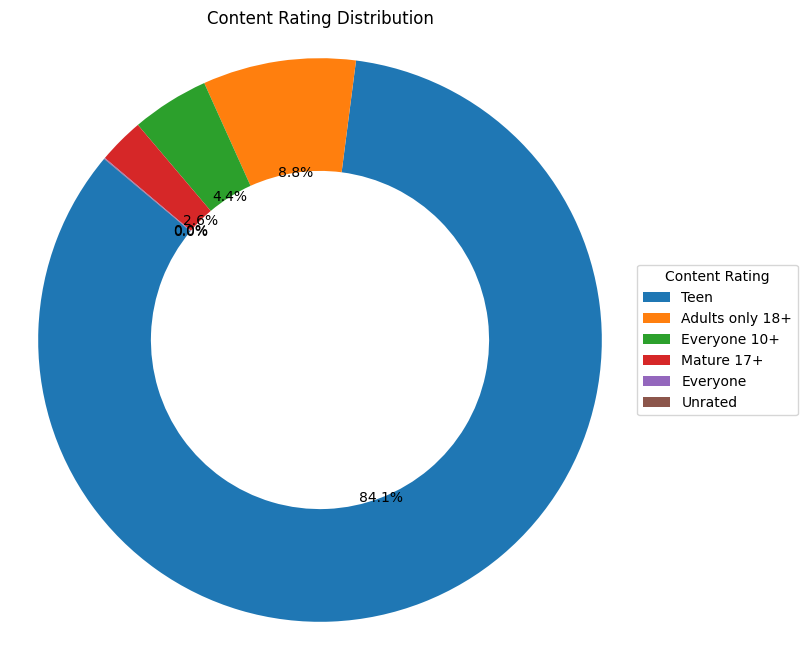

In [115]:
plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    content_counts,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4)  # donut
)

plt.legend(
    wedges,
    labels,
    title="Content Rating",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Content Rating Distribution")

plt.axis('equal')

plt.show()

## Real-Time Prediction Function

In [68]:
def predict_app(app_data):

    input_df = pd.DataFrame([app_data])

    prediction = dt_small.predict(input_df)[0]

    return prediction

In [69]:
from sklearn.tree import _tree

def explain_decision(tree, feature_names, input_data):

    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    node_indicator = tree.decision_path(input_data)
    leaf_id = tree.apply(input_data)

    print("\nDecision Path:\n")

    for node_id in node_indicator.indices:
        
        if leaf_id[0] == node_id:
            continue
            
        feature = feature_name[node_id]
        threshold = tree_.threshold[node_id]

        if input_data[0][tree_.feature[node_id]] <= threshold:
            print(f"{feature} <= {threshold:.2f}")
        else:
            print(f"{feature} > {threshold:.2f}")

In [79]:
reviews = int(input("Enter Reviews: "))
installs = int(input("Enter Installs: "))

sample = {
    'Category': 4,
    'Reviews': reviews,
    'Size': 20000000,
    'Installs': installs,
    'Type': 0,
    'Price': 0,
    'Content Rating': 1,
    'Genres': 10
}

In [80]:
import numpy as np

input_df = pd.DataFrame([sample])

prediction = dt_small.predict(input_df)[0]

print("Predicted Class:", prediction)

Predicted Class: 2


In [81]:
explain_decision(
    dt_small,
    X.columns,
    input_df.values # type: ignore
)


Decision Path:

Reviews > 5718.50
Reviews > 23117.00
Genres <= 24.50


c:\Users\ANKIT AGRAWAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\ANKIT AGRAWAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
